# 닫힌 구간에서의 최대·최소

$f$가 $[a,b]$에서 연속이면 **최대값·최소값**이 반드시 존재하고, 그 후보는

1. **임계점**: $f'(c)=0$ (또는 미분불가능) 이고 $a < c < b$
2. **끝점**: $x=a$, $x=b$

## 1. 절차 (미적분)

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x', real=True)

f = (x - 1)*(x - 2)*(x - 3)
df = sp.diff(f, x)
a, b = -1, 4  # 닫힌 구간

print("f(x) =")
display(sp.expand(f))
print("f'(x) =")
display(sp.expand(df))
print(f"구간: [{a}, {b}]")

f(x) =


f'(x) =


구간: [-1, 4]


## 2. 임계점 + 끝점 비교

In [2]:
crit = sp.solve(sp.Eq(df, 0), x)
crit_in = [c for c in crit if a < c < b]

candidates = [sp.Integer(a)] + crit_in + [sp.Integer(b)]
print("후보 x:")
display(candidates)

values = [(c, f.subs(x, c)) for c in candidates]
for c, v in values:
    print(f"  f({c}) = {v}")

# 최대·최소
vmax = max(values, key=lambda t: t[1])
vmin = min(values, key=lambda t: t[1])
print(f"\n최댓값: f({vmax[0]}) = {vmax[1]}")
print(f"최솟값: f({vmin[0]}) = {vmin[1]}")

후보 x:


  f(-1) = -24
  f(2 - sqrt(3)/3) = -sqrt(3)*(-1 - sqrt(3)/3)*(1 - sqrt(3)/3)/3
  f(sqrt(3)/3 + 2) = sqrt(3)*(-1 + sqrt(3)/3)*(sqrt(3)/3 + 1)/3
  f(4) = 6

최댓값: f(4) = 6
최솟값: f(-1) = -24


**후보 집합**: <br>
=> $\{a\} \cup \{c : f'(c)=0,\ a<c<b\} \cup \{b\}$

**max/min over candidates**: <br>
=> 연속함수의 닫힌구간 정리에 따른 정확한 방법

## 3. Example: $f(x)=x^3-3x$ on $[-2,2]$

In [3]:
f2 = x**3 - 3*x
df2 = sp.diff(f2, x)
A, B = -2, 2

crit2 = [c for c in sp.solve(df2, x) if A < c < B]
cands2 = [A] + crit2 + [B]
vals2 = [(c, f2.subs(x, c)) for c in cands2]

print("후보:")
for c, v in vals2:
    print(f"  f({c}) = {v}")

print("최대:", max(vals2, key=lambda t: t[1]))
print("최소:", min(vals2, key=lambda t: t[1]))

후보:
  f(-2) = -2
  f(-1) = 2
  f(1) = -2
  f(2) = 2
최대: (-1, 2)
최소: (-2, -2)


## 4. 그래프 (후보 표시)

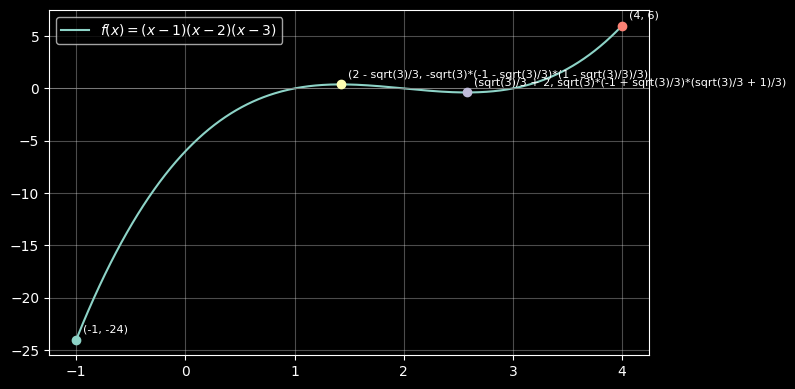

In [5]:
f_num = sp.lambdify(x, f, 'numpy')
xs = np.linspace(float(a), float(b), 400)
ys = f_num(xs)

plt.figure(figsize=(8, 4))
plt.plot(xs, ys, label=r"$f(x)=(x-1)(x-2)(x-3)$")
for c, v in values:
    plt.scatter([float(c)], [float(v)], zorder=5)
    plt.annotate(f"({c}, {v})", (float(c), float(v)), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.axhline(0, color="gray", lw=0.6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()